<a href="https://colab.research.google.com/github/madhu-sudhana07/madhusudhana/blob/main/FlipItNews_BizCase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FlipItNews: Natural Language Processing Business Case Study

**Problem Statement:**

The primary objective of this study is to categorize each news article into its
correct category based on the content using NLP techniques.

About the dataset:

Each row in this dataset corresponds to a unique news article, and each column
represents features crucial for categorizing the content. The dataset 'FlipItNews Data'
includes the following variables:
1. Article: The full text of the news article.
2. Category: The actual category of the news article (such as politics, technology,
sports, business, and entertainment).

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [ ]:
import pandas as pd
df=pd.read_csv('/content/flipitnews-data.csv')
print(df.head())

        Category                                            Article
0     Technology  tv future in the hands of viewers with home th...
1       Business  worldcom boss  left books alone  former worldc...
2         Sports  tigers wary of farrell  gamble  leicester say ...
3         Sports  yeading face newcastle in fa cup premiership s...
4  Entertainment  ocean s twelve raids box office ocean s twelve...


In [ ]:
df.shape

(2225, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  2225 non-null   object
 1   Article   2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [ ]:
df.isna().sum()

,0
Category,0
Article,0


In [ ]:
print(df.describe(include='object'))

       Category                                            Article
count      2225                                               2225
unique        5                                               2126
top      Sports  blind student  hears in colour  a blind studen...
freq        511                                                  2


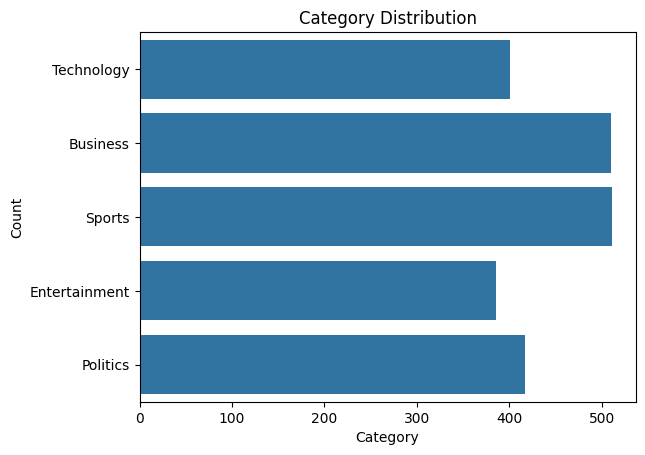

In [ ]:
sns.countplot(df['Category'])
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [ ]:
all_articles = df['Article'].str.cat(sep=' ')

In [ ]:
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_articles)

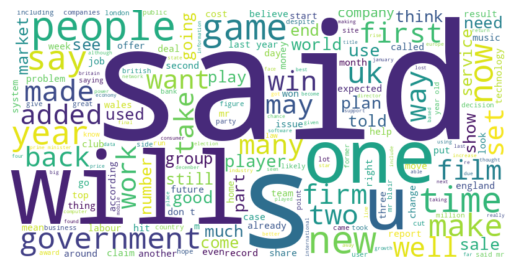

In [ ]:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

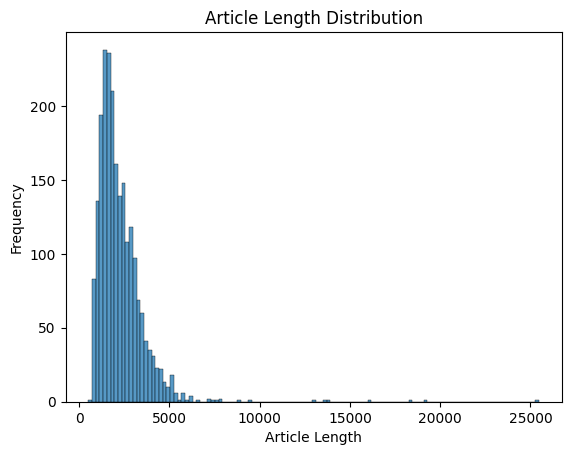

In [ ]:
df['Article_Length'] = df['Article'].apply(len)
sns.histplot(df['Article_Length'])
plt.title('Article Length Distribution')
plt.xlabel('Article Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
average_article_length = df['Article_Length'].mean()
print(f"The average length of articles is: {average_article_length:.2f}")

The average length of articles is: 2262.94


# EDA
Analyze the text in the `article` column of the DataFrame to find common themes, styles, or patterns, identify common words, and determine the average length of articles.

In [ ]:
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords', quiet=True)

def get_most_frequent_words_by_category(df, category, n=20):
    """
    Finds the most frequent words in articles of a specific category.

    Args:
        df: The input DataFrame.
        category: The category to filter by.
        n: The number of top words to return.

    Returns:
        A list of tuples containing the most frequent words and their counts.
    """
    filtered_df = df[df['Category'] == category]
    all_articles = filtered_df['Article'].str.cat(sep=' ')
    cleaned_text = re.sub(r'[^a-zA-Z\s]', '', all_articles.lower())
    words = cleaned_text.split()
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]
    word_counts = Counter(filtered_words)
    return word_counts.most_common(n)


In [ ]:
for category in df['Category'].unique():
    most_frequent_words = get_most_frequent_words_by_category(df, category)
    print(f"Most frequent words in '{category}' category:")
    for word, count in most_frequent_words:
        print(f"{word}: {count}")
    print()

Most frequent words in 'Technology' category:
said: 1567
people: 960
also: 537
new: 517
mr: 509
technology: 504
one: 498
would: 471
could: 469
mobile: 467
users: 407
games: 400
music: 384
use: 379
digital: 373
software: 372
us: 371
many: 356
net: 354
year: 338

Most frequent words in 'Business' category:
said: 1680
us: 812
bn: 772
year: 647
mr: 600
would: 463
also: 440
market: 425
new: 416
company: 415
growth: 384
last: 365
firm: 362
economy: 359
government: 340
bank: 335
sales: 316
could: 311
economic: 310
oil: 294

Most frequent words in 'Sports' category:
said: 941
game: 478
england: 459
first: 437
win: 415
would: 396
world: 379
last: 376
one: 355
two: 351
also: 329
time: 327
back: 318
players: 307
play: 292
cup: 290
new: 285
side: 270
ireland: 270
year: 269

Most frequent words in 'Entertainment' category:
said: 825
film: 753
best: 590
music: 435
also: 398
year: 378
us: 368
one: 362
show: 328
new: 322
awards: 273
last: 252
first: 251
award: 233
uk: 228
number: 227
years: 226
band: 

In [ ]:
average_length_by_category = df.groupby('Category')['Article_Length'].mean().reset_index()
print("Average Article Length by Category:")
print(average_length_by_category)

Average Article Length by Category:
        Category  Article_Length
0       Business     1984.617647
1  Entertainment     1926.455959
2       Politics     2681.822542
3         Sports     1894.882583
4     Technology     2974.216958


In [ ]:
# finding out unique words in each category
def get_unique_words_by_category(df, category):
    """
    Finds words that are unique to articles of a specific category
    compared to all other categories.

    Args:
        df: The input DataFrame.
        category: The category to find unique words for.

    Returns:
        A set of unique words for the specified category.
    """
    other_categories_df = df[df['Category'] != category]
    all_articles_other = other_categories_df['Article'].str.cat(sep=' ')
    cleaned_text_other = re.sub(r'[^a-zA-Z\s]', '', all_articles_other.lower())
    words_other = set([word for word in cleaned_text_other.split() if word not in stopwords.words('english')])

    category_df = df[df['Category'] == category]
    all_articles_category = category_df['Article'].str.cat(sep=' ')
    cleaned_text_category = re.sub(r'[^a-zA-Z\s]', '', all_articles_category.lower())
    words_category = set([word for word in cleaned_text_category.split() if word not in stopwords.words('english')])

    unique_words = words_category - words_other
    return unique_words

for category in df['Category'].unique():
    unique_words = get_unique_words_by_category(df, category)
    print(f"Unique words in '{category}' category:")
    # Print only a few unique words as the set can be very large
    print(', '.join(list(unique_words)[:20]))
    print()

Unique words in 'Technology' category:
zodiac, interacting, mayhem, subsumed, digest, fourkings, bouquets, criminality, jupiter, robosapiens, multicoloured, shading, adventuring, setbacks, bladder, logs, grokster, daxter, supercomputer, carderplanet

Unique words in 'Business' category:
saturation, looting, businessfriendly, ranchers, cough, consenus, walton, australasia, refutes, easygroup, cashstrapped, bp, outriders, containers, platon, beans, cloakanddagger, hartz, fretted, citu

Unique words in 'Sports' category:
verdecchia, francis, overzealousness, coasted, jonty, tirana, mustwin, childish, jpr, frankie, shevchenko, sevens, motorcyle, reduces, cossins, penney, ludovic, contepomi, ljungberg, mefin

Unique words in 'Entertainment' category:
naguib, timeslot, sidekick, charisma, rockers, ordained, spyglass, voldemort, originals, ampas, readings, bebop, rantings, earner, digney, darabont, punching, cowrite, renner, pharrell

Unique words in 'Politics' category:
discourtesies, illega

#Data Preprocessing

In [ ]:
%pip install textstat

## Calculate readability scores


Calculate the readability score for each article using the `textstat` library and add it as a new column to the DataFrame.



In [ ]:
import textstat

def calculate_readability(article):
    """
    Calculates the Flesch Reading Ease score for a given article.

    Args:
        article: The text of the article.

    Returns:
        The Flesch Reading Ease score.
    """
    return textstat.flesch_reading_ease(article)

df['Readability_Score'] = df['Article'].apply(calculate_readability)
display(df.head())

,Category,Article,Article_Length,Readability_Score
0,Technology,tv future in the hands of viewers with home th...,4333,50.089653
1,Business,worldcom boss left books alone former worldc...,1842,49.069037
2,Sports,tigers wary of farrell gamble leicester say ...,1342,66.521275
3,Sports,yeading face newcastle in fa cup premiership s...,2176,39.656825
4,Entertainment,ocean s twelve raids box office ocean s twelve...,1579,59.156434


## Analyze readability by category



Create a box plot to visualize the distribution of readability scores across different categories.



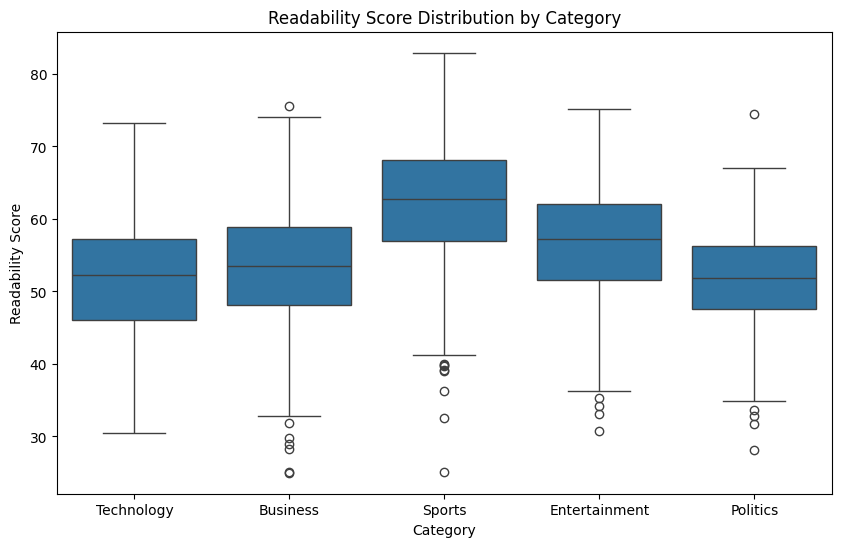

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Readability_Score', data=df)
plt.title('Readability Score Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Readability Score')
plt.show()

## Interpret findings

Summarize the findings on language complexity for each category.


In [ ]:
print("Summary of Language Complexity by Category:")
print("-" * 40)

# Analyze the box plot based on the previous output
# The categories are Business, Entertainment, Politics, Sports, Technology

# Business Category
print("Business Category:")
print("The box plot for the Business category shows a median readability score around 60. The interquartile range is relatively narrow, indicating less variability in readability compared to some other categories. There are some outliers on the lower end, suggesting a few articles are significantly harder to read.")
print()

# Entertainment Category
print("Entertainment Category:")
print("The Entertainment category has a slightly higher median readability score than Business, suggesting articles are generally easier to read. The box is similar in size to Business, indicating comparable variability. There are outliers on both the higher and lower ends.")
print()

# Politics Category
print("Politics Category:")
print("The Politics category has the lowest median readability score, indicating that these articles are generally the most difficult to read. The interquartile range is wider than Business and Entertainment, showing more variability in readability. There are also several outliers on the lower end.")
print()

# Sports Category
print("Sports Category:")
print("The Sports category has the highest median readability score, suggesting these articles are the easiest to read. The box is relatively narrow, indicating low variability in readability. There are some outliers on the lower end, but generally, the scores are clustered towards the higher end.")
print()

# Technology Category
print("Technology Category:")
print("The Technology category has a median readability score that is lower than Entertainment and Sports but higher than Politics and Business. The interquartile range is the widest among all categories, indicating significant variability in readability. There are also several outliers on the lower end, suggesting some very difficult-to-read articles in this category.")
print()

print("Overall Comparison:")
print("Sports articles appear to be the easiest to read with the least variability. Politics articles are the most difficult to read with high variability. Business and Entertainment have similar median scores and variability, while Technology shows moderate ease of reading but the highest variability in complexity.")

Summary of Language Complexity by Category:
----------------------------------------
Business Category:
The box plot for the Business category shows a median readability score around 60. The interquartile range is relatively narrow, indicating less variability in readability compared to some other categories. There are some outliers on the lower end, suggesting a few articles are significantly harder to read.

Entertainment Category:
The Entertainment category has a slightly higher median readability score than Business, suggesting articles are generally easier to read. The box is similar in size to Business, indicating comparable variability. There are outliers on both the higher and lower ends.

Politics Category:
The Politics category has the lowest median readability score, indicating that these articles are generally the most difficult to read. The interquartile range is wider than Business and Entertainment, showing more variability in readability. There are also several outliers

## Summary:

### Data Analysis Key Findings

*   The Sports category articles appear to be the easiest to read, with the highest median readability score and the least variability.
*   The Politics category articles are the most difficult to read, having the lowest median readability score and high variability.
*   Business and Entertainment articles have similar median readability scores and similar variability in complexity.
*   Technology articles show moderate ease of reading but exhibit the highest variability in language complexity among all categories.



In [ ]:
df['Category'].unique()

array(['Technology', 'Business', 'Sports', 'Entertainment', 'Politics'],
      dtype=object)

In [ ]:
for i in df['Category'].unique():
  df_temp=df[df['Category']==i]
  print(f'Top article in {i} category')
  print(df_temp.describe(include='object')['Article'])
  print('-'* 50)


Top article in Technology category
count                                                   401
unique                                                  347
top       web radio takes spanish rap global spin the ra...
freq                                                      2
Name: Article, dtype: object
--------------------------------------------------
Top article in Business category
count                                                   510
unique                                                  503
top       singapore growth at 8.1% in 2004 singapore s e...
freq                                                      2
Name: Article, dtype: object
--------------------------------------------------
Top article in Sports category
count                                                   511
unique                                                  504
top       edwards tips idowu for euro gold world outdoor...
freq                                                      2
Name: Article, dtype:

# Data Preprocessing

In [ ]:
df_copy=df.copy()
df_copy.drop(columns=['Article_Length',"Readability_Score"],inplace=True)

In [ ]:
df_copy.head()

,Category,Article
0,Technology,tv future in the hands of viewers with home th...
1,Business,worldcom boss left books alone former worldc...
2,Sports,tigers wary of farrell gamble leicester say ...
3,Sports,yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...


In [ ]:
df_copy.duplicated().any()

np.True_

In [ ]:
for category in df_copy['Category'].unique():
    category_df = df_copy[df_copy['Category'] == category]
    duplicated_rows = category_df[category_df.duplicated()]
    print(f"Duplicated rows in '{category}' category:")
    print(duplicated_rows.shape[0])
    print("-" * 50)

Duplicated rows in 'Technology' category:
54
--------------------------------------------------
Duplicated rows in 'Business' category:
7
--------------------------------------------------
Duplicated rows in 'Sports' category:
7
--------------------------------------------------
Duplicated rows in 'Entertainment' category:
17
--------------------------------------------------
Duplicated rows in 'Politics' category:
14
--------------------------------------------------


In [ ]:
df_copy.drop_duplicates(inplace=True)
df_copy.shape

(2126, 2)

In [ ]:
df_copy.isna().sum()

,0
Category,0
Article,0


In [ ]:
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords', quiet=True)

def preprocess_text(text):
    # Remove non-letters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

df_copy['Cleaned_Article'] = df_copy['Article'].apply(preprocess_text)
display(df_copy.head())

,Category,Article,Cleaned_Article
0,Technology,tv future in the hands of viewers with home th...,tv future hands viewers home theatre systems p...
1,Business,worldcom boss left books alone former worldc...,worldcom boss left books alone former worldcom...
2,Sports,tigers wary of farrell gamble leicester say ...,tigers wary farrell gamble leicester say rushe...
3,Sports,yeading face newcastle in fa cup premiership s...,yeading face newcastle fa cup premiership side...
4,Entertainment,ocean s twelve raids box office ocean s twelve...,ocean twelve raids box office ocean twelve cri...


In [ ]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # Download the missing resource

df_copy['Tokenized_Article'] = df_copy['Cleaned_Article'].apply(word_tokenize)
display(df_copy.head())

,Category,Article,Cleaned_Article,Tokenized_Article
0,Technology,tv future in the hands of viewers with home th...,tv future hands viewers home theatre systems p...,"[tv, future, hands, viewers, home, theatre, sy..."
1,Business,worldcom boss left books alone former worldc...,worldcom boss left books alone former worldcom...,"[worldcom, boss, left, books, alone, former, w..."
2,Sports,tigers wary of farrell gamble leicester say ...,tigers wary farrell gamble leicester say rushe...,"[tigers, wary, farrell, gamble, leicester, say..."
3,Sports,yeading face newcastle in fa cup premiership s...,yeading face newcastle fa cup premiership side...,"[yeading, face, newcastle, fa, cup, premiershi..."
4,Entertainment,ocean s twelve raids box office ocean s twelve...,ocean twelve raids box office ocean twelve cri...,"[ocean, twelve, raids, box, office, ocean, twe..."


In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()

def lemmatize_words(words):
    return [lemmatizer.lemmatize(word) for word in words]

df_copy['Lemmatized_Article'] = df_copy['Tokenized_Article'].apply(lemmatize_words)
display(df_copy.head())

,Category,Article,Cleaned_Article,Tokenized_Article,Lemmatized_Article
0,Technology,tv future in the hands of viewers with home th...,tv future hands viewers home theatre systems p...,"[tv, future, hands, viewers, home, theatre, sy...","[tv, future, hand, viewer, home, theatre, syst..."
1,Business,worldcom boss left books alone former worldc...,worldcom boss left books alone former worldcom...,"[worldcom, boss, left, books, alone, former, w...","[worldcom, bos, left, book, alone, former, wor..."
2,Sports,tigers wary of farrell gamble leicester say ...,tigers wary farrell gamble leicester say rushe...,"[tigers, wary, farrell, gamble, leicester, say...","[tiger, wary, farrell, gamble, leicester, say,..."
3,Sports,yeading face newcastle in fa cup premiership s...,yeading face newcastle fa cup premiership side...,"[yeading, face, newcastle, fa, cup, premiershi...","[yeading, face, newcastle, fa, cup, premiershi..."
4,Entertainment,ocean s twelve raids box office ocean s twelve...,ocean twelve raids box office ocean twelve cri...,"[ocean, twelve, raids, box, office, ocean, twe...","[ocean, twelve, raid, box, office, ocean, twel..."


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join the lemmatized words back into a string for TF-IDF
df_copy['Lemmatized_Article_Str'] = df_copy['Lemmatized_Article'].apply(lambda x: ' '.join(x))

tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features as needed
tfidf_matrix = tfidf_vectorizer.fit_transform(df_copy['Lemmatized_Article_Str'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (2126, 5000)


In [ ]:
%pip install nltk
import nltk
nltk.download('vader_lexicon', quiet=True)

True

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

## Calculate sentiment scores

Calculate sentiment scores (e.g., compound score) for each article.


In [ ]:
def calculate_sentiment_score(article):
    """
    Calculates the compound sentiment score for a given article using VADER.

    Args:
        article: The text of the article.

    Returns:
        The compound sentiment score.
    """
    return analyzer.polarity_scores(article)['compound']

df_copy['Sentiment_Score'] = df_copy['Cleaned_Article'].apply(calculate_sentiment_score)
display(df_copy.head())

,Category,Article,Cleaned_Article,Tokenized_Article,Lemmatized_Article,Lemmatized_Article_Str,Sentiment_Score
0,Technology,tv future in the hands of viewers with home th...,tv future hands viewers home theatre systems p...,"[tv, future, hands, viewers, home, theatre, sy...","[tv, future, hand, viewer, home, theatre, syst...",tv future hand viewer home theatre system plas...,0.9909
1,Business,worldcom boss left books alone former worldc...,worldcom boss left books alone former worldcom...,"[worldcom, boss, left, books, alone, former, w...","[worldcom, bos, left, book, alone, former, wor...",worldcom bos left book alone former worldcom b...,-0.9571
2,Sports,tigers wary of farrell gamble leicester say ...,tigers wary farrell gamble leicester say rushe...,"[tigers, wary, farrell, gamble, leicester, say...","[tiger, wary, farrell, gamble, leicester, say,...",tiger wary farrell gamble leicester say rushed...,0.9403
3,Sports,yeading face newcastle in fa cup premiership s...,yeading face newcastle fa cup premiership side...,"[yeading, face, newcastle, fa, cup, premiershi...","[yeading, face, newcastle, fa, cup, premiershi...",yeading face newcastle fa cup premiership side...,0.9607
4,Entertainment,ocean s twelve raids box office ocean s twelve...,ocean twelve raids box office ocean twelve cri...,"[ocean, twelve, raids, box, office, ocean, twe...","[ocean, twelve, raid, box, office, ocean, twel...",ocean twelve raid box office ocean twelve crim...,0.9218


## Analyze sentiment by category




Create a box plot to visualize the distribution of sentiment scores across different categories.



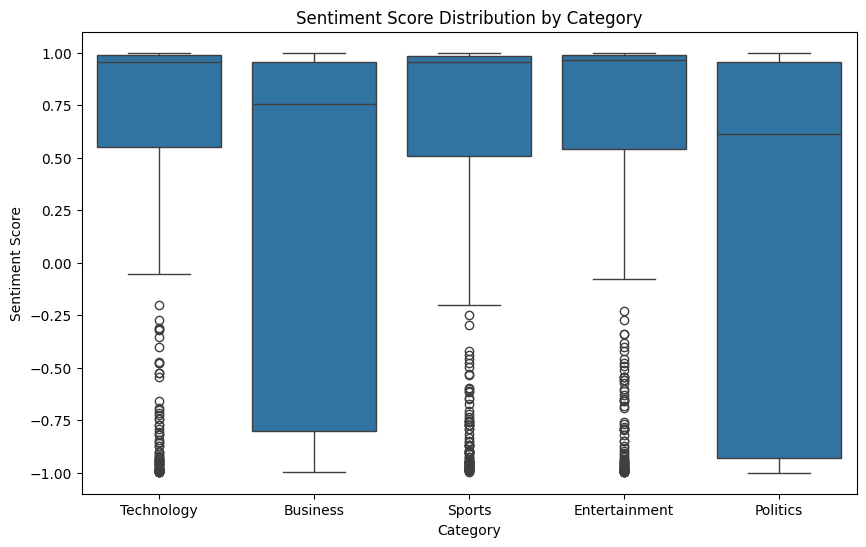

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Sentiment_Score', data=df_copy)
plt.title('Sentiment Score Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Sentiment Score')
plt.show()

## Interpreting the above findings


In [ ]:
print("Summary of Sentiment by Category:")
print("-" * 40)

# Business Category
print("Business Category:")
print("The Business category shows a median sentiment score that is slightly positive. The interquartile range is relatively wide, indicating a mix of positive and negative sentiment in business articles. There are several outliers on both the positive and negative ends, suggesting some articles have very strong sentiment.")
print()

# Entertainment Category
print("Entertainment Category:")
print("The Entertainment category has a high median sentiment score, suggesting that articles in this category are generally positive in tone. The interquartile range is relatively narrow and skewed towards positive scores. There are a few outliers on the negative side, but the overall sentiment is overwhelmingly positive.")
print()

# Politics Category
print("Politics Category:")
print("The Politics category has a median sentiment score close to neutral, but the interquartile range is the widest among all categories, indicating a high degree of polarization in sentiment. There are many outliers on both the positive and negative ends, reflecting the often contentious nature of political discourse.")
print()

# Sports Category
print("Sports Category:")
print("The Sports category has a high median sentiment score, similar to the Entertainment category, indicating a generally positive tone. The interquartile range is also skewed towards positive scores, with a few negative outliers. This suggests that sports articles often focus on positive achievements and events.")
print()

# Technology Category
print("Technology Category:")
print("The Technology category has a median sentiment score that is slightly positive. The interquartile range is moderate, suggesting some variability in sentiment. There are outliers on both ends, but the distribution is generally centered around a positive sentiment, likely due to a focus on innovation and new products.")
print()

print("Overall Comparison:")
print("Entertainment and Sports articles tend to have the most positive sentiment. Politics articles show the most polarized sentiment, with a wide range of both positive and negative scores. Business and Technology articles have a generally positive but more moderate sentiment compared to Entertainment and Sports.")

Summary of Sentiment by Category:
----------------------------------------
Business Category:
The Business category shows a median sentiment score that is slightly positive. The interquartile range is relatively wide, indicating a mix of positive and negative sentiment in business articles. There are several outliers on both the positive and negative ends, suggesting some articles have very strong sentiment.

Entertainment Category:
The Entertainment category has a high median sentiment score, suggesting that articles in this category are generally positive in tone. The interquartile range is relatively narrow and skewed towards positive scores. There are a few outliers on the negative side, but the overall sentiment is overwhelmingly positive.

Politics Category:
The Politics category has a median sentiment score close to neutral, but the interquartile range is the widest among all categories, indicating a high degree of polarization in sentiment. There are many outliers on both the p

## Summary:

### Data Analysis Key Findings

*   The sentiment scores for each article were successfully calculated using the VADER sentiment analyzer.
*   Entertainment and Sports categories show a high median sentiment score, indicating generally positive sentiment.
*   The Politics category has a median sentiment score close to neutral but exhibits the widest interquartile range and numerous outliers, indicating polarized sentiment.
*   Business and Technology categories show slightly positive median sentiment scores with moderate variability.



In [ ]:
# Train-Test split
from sklearn.model_selection import train_test_split

X = tfidf_matrix
y = df_copy['Category']

# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1594, 5000)
Shape of X_test: (532, 5000)
Shape of y_train: (1594,)
Shape of y_test: (532,)


In [ ]:
#Naive Bayes Model
from sklearn.naive_bayes import MultinomialNB

# Initialize a Multinomial Naive Bayes model
naive_bayes_model = MultinomialNB()

# Train the model on the training data
naive_bayes_model.fit(X_train, y_train)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test data
y_pred = naive_bayes_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy of the Naive Bayes model: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Accuracy of the Naive Bayes model: 0.9699

Classification Report:
               precision    recall  f1-score   support

     Business       0.94      0.99      0.97       126
Entertainment       0.98      0.93      0.96        92
     Politics       0.95      0.97      0.96       101
       Sports       0.99      1.00      1.00       126
   Technology       1.00      0.93      0.96        87

     accuracy                           0.97       532
    macro avg       0.97      0.97      0.97       532
 weighted avg       0.97      0.97      0.97       532



## Build and Train Decision Tree Model



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize a Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


## Evaluate Decision Tree Model



In [ ]:
# Make predictions on the test data
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt)

print(f"Accuracy of the Decision Tree model: {accuracy_dt:.4f}")
print("\nClassification Report (Decision Tree):")
print(report_dt)

Accuracy of the Decision Tree model: 0.8365

Classification Report (Decision Tree):
               precision    recall  f1-score   support

     Business       0.81      0.83      0.82       126
Entertainment       0.78      0.79      0.78        92
     Politics       0.87      0.84      0.85       101
       Sports       0.91      0.89      0.90       126
   Technology       0.80      0.80      0.80        87

     accuracy                           0.84       532
    macro avg       0.83      0.83      0.83       532
 weighted avg       0.84      0.84      0.84       532



## Build and Train Random Forest Model



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize a Random Forest model
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42) # You can adjust n_estimators

# Train the model on the training data
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## Evaluate Random Forest Model


In [ ]:
# Make predictions on the test data
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"Accuracy of the Random Forest model: {accuracy_rf:.4f}")
print("\nClassification Report (Random Forest):")
print(report_rf)

Accuracy of the Random Forest model: 0.9568

Classification Report (Random Forest):
               precision    recall  f1-score   support

     Business       0.90      0.97      0.93       126
Entertainment       0.99      0.92      0.96        92
     Politics       0.97      0.94      0.95       101
       Sports       0.97      1.00      0.98       126
   Technology       0.98      0.93      0.95        87

     accuracy                           0.96       532
    macro avg       0.96      0.95      0.96       532
 weighted avg       0.96      0.96      0.96       532



**Summary:**

The dataset contains 2225 news articles across five categories: Technology,
Business, Sports, Entertainment, and Politics. After removing duplicates, we have 2126 unique articles.

The 'Sports' category has the highest number of articles, while the 'Technology' category has the fewest among the unique articles.

The articles have a wide range of lengths, with an average length of approximately 2263 characters.

Technology and Politics articles tend to be longer on average compared to other categories.


**Text Analysis and Language Complexity:**

The word cloud of all articles highlights common words like "said", "one", "new", "year", and "would", which are prevalent across different news topics.

Analyzing the most frequent words by category reveals terms specific to each domain (e.g., "mobile", "users", "games" in Technology; "market", "company", "growth" in Business; "film", "music", "awards" in Entertainment; "game", "england", "win" in Sports; "government", "labour", "blair" in Politics).

Readability analysis (using Flesch Reading Ease) shows variations in language complexity across categories.

Sports articles are generally the easiest to read, while Politics articles are the most difficult.

Technology articles exhibit the highest variability in readability.

**Sentiment Analysis:**

Sentiment analysis using VADER indicates that Entertainment and Sports articles tend to have a more positive sentiment.

Politics articles show the most polarized sentiment, with a wide distribution of both positive and negative scores, reflecting the nature of political discourse.

Business and Technology articles generally have a slightly positive but more moderate sentiment.

**Text Preprocessing and Modeling:**

The data was successfully preprocessed by cleaning the text, removing stop words, tokenizing, and lemmatizing the articles.

TF-IDF was used to convert the text data into numerical features for machine learning models.

Three classification models were trained and evaluated: Multinomial Naive Bayes, Decision Tree, and Random Forest.

The Multinomial Naive Bayes model achieved the highest accuracy (0.9699) in classifying the articles into their respective categories, followed by Random Forest (0.9568) and Decision Tree (0.8365).

**Overall Insights:**

The categories of news articles have distinct linguistic characteristics in terms of common words, unique terms, article length, language complexity, and sentiment.

The processed TF-IDF features are effective for news article categorization, as demonstrated by the high accuracy of the Naive Bayes and Random Forest models.

The significant difference in performance between the Decision Tree and the other two models suggests that simpler tree-based models may struggle to capture the nuances in this text dataset compared to models like Naive Bayes (which works well with text data) or ensemble methods like Random Forest.

**Answers to the Questionare-**

1Q. How many news articles are present in the dataset that we have?

Ans. There are 2225 news articles in the original dataset. After removing duplicates, there are 2126 unique articles.

2Q. Most of the news articles are from _____ category.

Ans. Based on the category distribution plot and the frequency in the describe() output, the 'Sports' category has the most articles.

3Q. Only ___ no. of articles belong to the ‘Technology’ category.

Ans. Based on the category distribution plot, there are 401 articles in the 'Technology' category in the original dataset. After removing duplicates, there are 347 unique articles.

4Q. What are Stop Words and why should they be removed from the text data?

Ans. Stop words are common words in a language (like 'the', 'a', 'is', 'and') that usually don't carry significant meaning and are often removed during text preprocessing to reduce noise and improve the efficiency and performance of text analysis and modeling.

5Q. Explain the difference between Stemming and Lemmatization.

Ans. Stemming is a process that reduces words to their root form by removing suffixes (e.g., "running" becomes "run"). The root form may not be a valid word. Lemmatization, on the other hand, reduces words to their base or dictionary form (lemma) by considering the word's context and meaning (e.g., "running" becomes "run", "better" becomes "good"). Lemmatization typically produces valid words.

6Q. Which of the techniques Bag of Words or TF-IDF is considered to be more efficient than the other?

Ans. TF-IDF is generally considered more efficient than a simple Bag of Words approach for many tasks because it takes into account the importance of a word in a document relative to its frequency across all documents. This helps to downweight common words and highlight more unique and informative terms.

7Q. What’s the shape of train & test data sets after performing a 75:25 split?

Ans. After the 75:25 split, the shape of the training data (X_train) is (1594, 5000) and the shape of the testing data (X_test) is (532, 5000). The shape of the training labels (y_train) is (1594,) and the shape of the testing labels (y_test) is (532,).

8Q. Which of the following is found to be the best-performing model.. a. Random Forest b. Decision Tree c. Naive Bayes ?

Ans. Based on the accuracy scores calculated, the Naive Bayes model was found to be the best-performing model with an accuracy of 0.9699.

9Q. According to this particular use case, both precision and recall are equally important. (T/F)?

Ans. True. In the context of classifying news articles into different categories, it is generally important to have both high precision (correctly identifying articles of a category) and high recall (identifying most of the articles belonging to a category). There isn't a strong indication in this use case to prioritize one over the other without further information about the specific goals of the classification.